In [1]:
#log Transformation

In [7]:
#brightnesss dark regions compresses bright regions

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# Load image
img = cv2.imread("image.jpeg",cv2.IMREAD_GRAYSCALE)
img_float=img.astype(np.float32)
img_float=np.clip(img_float,0,255)


In [94]:
c=255/np.log(1+255)

In [95]:
log_transformed=c*np.log(1+img)
log_transformed=np.clip(log_transformed,0,255)
log_transformed=log_transformed.astype(np.uint8)

C:\Users\2022ict90\AppData\Local\Temp\ipykernel_14164\689158026.py:1: RuntimeWarning: divide by zero encountered in log
  log_transformed=c*np.log(1+img)


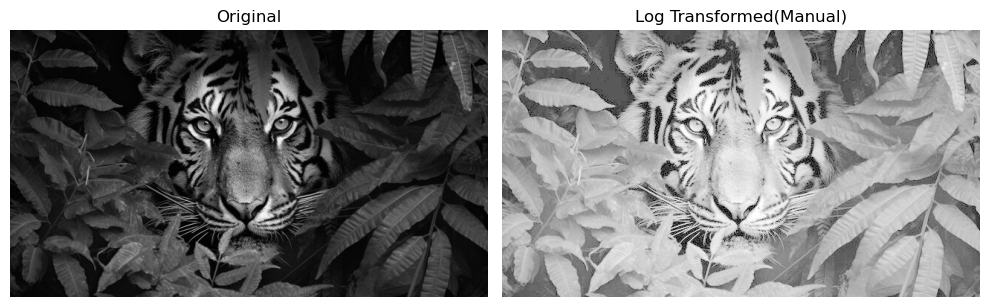

In [96]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8),cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(log_transformed,cmap="gray")
plt.title("Log Transformed(Manual)")
plt.axis("off")
plt.tight_layout()
plt.show()

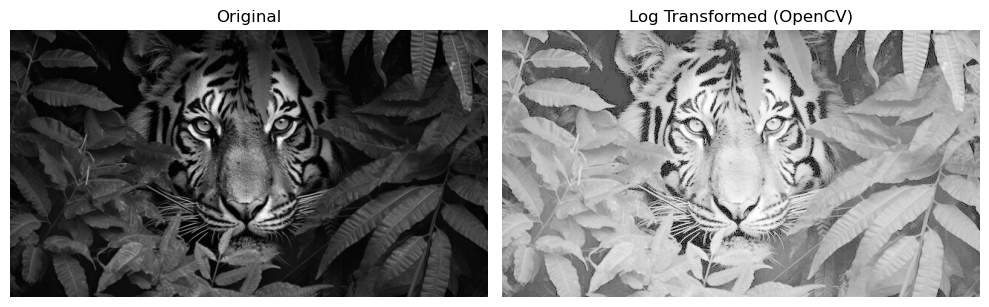

In [97]:
# img + 1
img_plus_one = img + 1

# Convert to float32
img_plus_one = img_plus_one.astype(np.float32)

# Calculate c
c = 255 / np.log(1 + np.max(img))

# OpenCV Log Transformation
log_cv2_raw = cv2.log(img_plus_one)

log_transformed_cv2 = c * log_cv2_raw
log_transformed_cv2 = np.clip(log_transformed_cv2, 0, 255)
log_transformed_cv2 = log_transformed_cv2.astype(np.uint8)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(log_transformed_cv2, cmap="gray")
plt.title("Log Transformed (OpenCV)")
plt.axis("off")

plt.tight_layout()
plt.show()

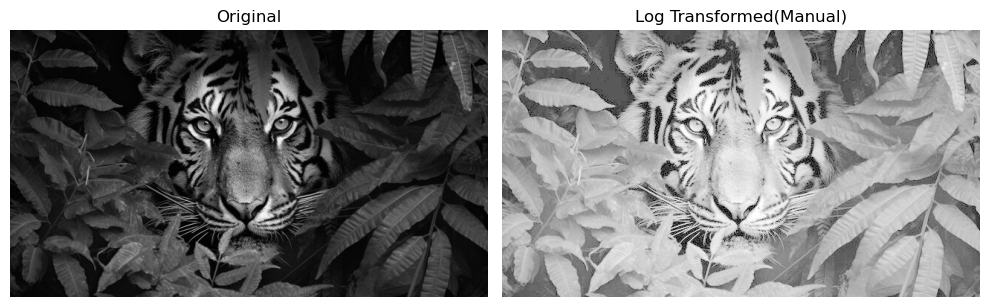

In [98]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8),cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(log_transformed,cmap="gray")
plt.title("Log Transformed(Manual)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [99]:
normalized=img/255.0


In [100]:
gamma_04=np.power(normalized,0.4)*255.0
gamma_04=np.clip(gamma_04,0,255)
gamma_04=gamma_04.astype(np.uint8)


In [101]:
gamma_10=np.power(normalized,1.0)*255.0
gamma_10=np.clip(gamma_04,0,255)
gamma_10=gamma_04.astype(np.uint8)



In [102]:
gamma_25=np.power(normalized,2.5)*255.0
gamma_25=np.clip(gamma_04,0,255)
gamma_25=gamma_04.astype(np.uint8)


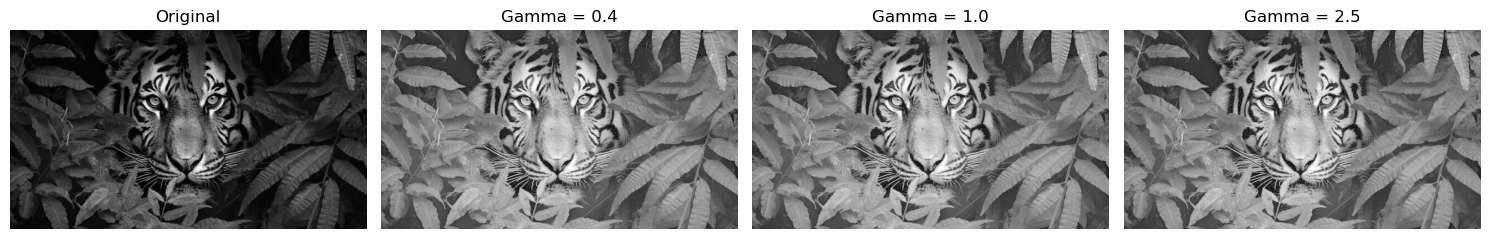

In [103]:
# Display all images
plt.figure(figsize=(15, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(img.astype(np.uint8), cmap="gray")
plt.title("Original")
plt.axis("off")

# Gamma 0.4
plt.subplot(1, 4, 2)
plt.imshow(gamma_04, cmap="gray")
plt.title("Gamma = 0.4")
plt.axis("off")

# Gamma 1.0
plt.subplot(1, 4, 3)
plt.imshow(gamma_10, cmap="gray")
plt.title("Gamma = 1.0")
plt.axis("off")

# Gamma 2.5
plt.subplot(1, 4, 4)
plt.imshow(gamma_25, cmap="gray")
plt.title("Gamma = 2.5")
plt.axis("off")

plt.tight_layout()
plt.show()

In [104]:
#Gamma Transformatrion useing openCVs built-in cv2.pow function 

In [105]:
normalized_float32=normalized.astype(np.float32)

In [106]:
# Gamma = 0.4
gamma_04_cv2 = cv2.pow(normalized, 0.4) * 255.0
gamma_04_cv2 = np.clip(gamma_04_cv2, 0, 255)
gamma_04_cv2 = gamma_04_cv2.astype(np.uint8)


In [107]:
# Gamma = 1.0
gamma_10_cv2 = cv2.pow(normalized, 1.0) * 255.0
gamma_10_cv2 = np.clip(gamma_10_cv2, 0, 255)
gamma_10_cv2 = gamma_10_cv2.astype(np.uint8)

In [108]:
# Gamma = 2.5
gamma_25_cv2 = cv2.pow(normalized, 2.5) * 255.0
gamma_25_cv2 = np.clip(gamma_25_cv2, 0, 255)
gamma_25_cv2 = gamma_25_cv2.astype(np.uint8)


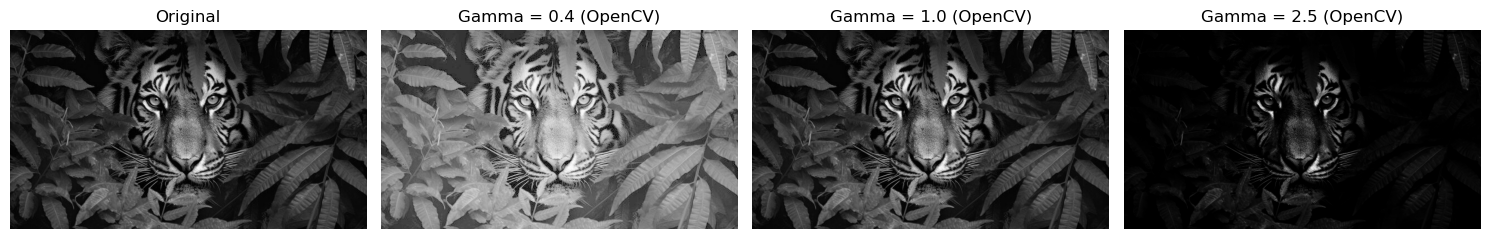

In [109]:
# Display results
plt.figure(figsize=(15, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(img.astype(np.uint8), cmap="gray")
plt.title("Original")
plt.axis("off")

# Gamma = 0.4
plt.subplot(1, 4, 2)
plt.imshow(gamma_04_cv2, cmap="gray")
plt.title("Gamma = 0.4 (OpenCV)")
plt.axis("off")

# Gamma = 1.0
plt.subplot(1, 4, 3)
plt.imshow(gamma_10_cv2, cmap="gray")
plt.title("Gamma = 1.0 (OpenCV)")
plt.axis("off")

# Gamma = 2.5
plt.subplot(1, 4, 4)
plt.imshow(gamma_25_cv2, cmap="gray")
plt.title("Gamma = 2.5 (OpenCV)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Piecewise linear transformation

### there is no OpenCV built-in for this wed build it manually using 
### boolean masks,one region at a time,with no custom function needed


In [110]:
r1,s1=70,20
r1,s1=70,20

## Piecewise Linear Transformation — Note

### Important Terms

- **s** → Output intensity
- **r** → Input intensity
- **r₁** → Input intensity where the first region ends
- **r₂** → Input intensity where the second region ends
- **s₁** → Output value corresponding to r₁
- **s₂** → Output value corresponding to r₂

### Regions

- **0 → r₁** → First linear transformation
- **r₁ → r₂** → Main stretching region
- **r₂ → L−1** → Third linear transformation

### Given Values

- r₁ = 80
- r₂ = 180
- s₁ = 30
- s₂ = 220

### Mapping

```text
Input:   80 --------------------------- 180
Output:  30 --------------------------- 220

In [111]:
r1,s1=70,20
r2,s2=180,230

In [112]:
piecewise_result=np.zeros_like(img)

In [113]:
region1=img < r1
piecewise_result[region1]=(s1/r1)*img[region1]

In [114]:
region2=(img >= r1)&(img >= r2)
piecewise_result[region2]=((s2-s1)/(r2-r1))*(img[region2]-r1) + s1

In [115]:
region3=img >= r2
piecewise_result[region3]=((255-s1)/(255-r1))*(img[region3]-r2) + s2

In [116]:
piecewise_result=np.clip(piecewise_result,0,255)
piecewise_result=piecewise_result.astype(np.uint8)


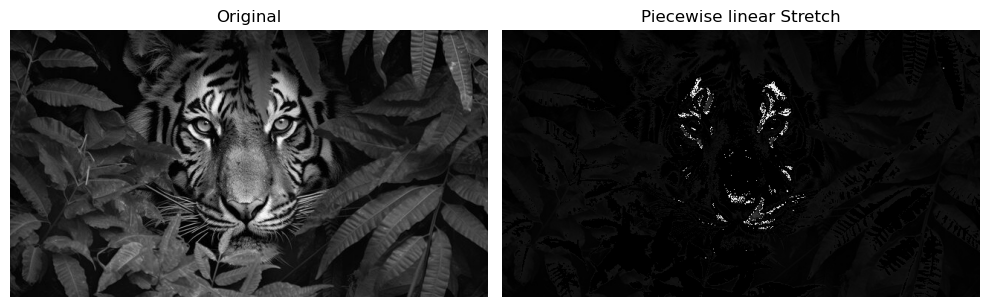

In [117]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img.astype(np.uint8),cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(piecewise_result,cmap="gray")
plt.title("Piecewise linear Stretch")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
Apply a log transformation to the image 
In the same figure area 
Apply a gamma transform with a gamma value of your own choosing somewhere between 0.1 and 0.5
Apply a second gamma transform with a gamma value of your own choosing somewhere between 2.0 and 4.0
In the same figure are display the original image and  both gamma transformed results side by side 

Apply a piecewise linear transformation to the image using control points of your own choosing 
Apply a second piecewise linear transformation to the image using different set of control points 
In  the same figure area display the original image and both piecewise transformed results side by side 